<a href="https://colab.research.google.com/github/lhrong16/Data-Science/blob/WIA1007-IDS/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tutorial 5 (Week 5)**

# **1. Incomplete data/Missing values**

In [ ]:
import numpy as np
import pandas as pd
#pd.read_csv() is a function called from pandas library
#df = pd.read_csv('salary.csv') # this command load salary.csv onto your dataframe named as df.
#You can mount the file on your google drive and load it. To make life easier, just make sure your directory doesn't have spaces
#Example /Dataset/machine learning <<<This directory has spaces
from google.colab import files
Data = files.upload()

Saving Ask A Manager Salary Survey 2021.csv to Ask A Manager Salary Survey 2021 (5).csv


In [ ]:
import io
df = pd.read_csv('Ask A Manager Salary Survey 2021.csv')
#Convert "salary" string to integers
df['Salary'] = df['Salary'].replace(',','',regex=True) #this replace the comma ',' in 55,000 to 55000
df['Salary'] = df['Salary'].astype(int) # this convert the column datatypes from object into numbers , in this case integer
df.head()

,Timestamp,Age,Industry,Job title,Context,Salary,Compensation,Currency,Other currency,Salary context,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,55000,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,54600,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,34000,NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,62000,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,60000,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [ ]:
df['Salary'].mean() #Getting the stats for one column/feature

361173.6368587804

In [ ]:
df.describe() # Getting the stats for all co

,Salary,Compensation
count,2.809100e+04,2.078300e+04
mean,3.611736e+05,1.815167e+04
std,3.620405e+07,8.337120e+05
min,0.000000e+00,0.000000e+00
25%,5.400000e+04,0.000000e+00
50%,7.500000e+04,2.000000e+03
75%,1.097345e+05,1.000000e+04
max,6.000070e+09,1.200000e+08


In [ ]:
df['Salary']

,Salary
0,55000
1,54600
2,34000
3,62000
4,60000
...,...
28086,8000
28087,50000
28088,10000
28089,4740


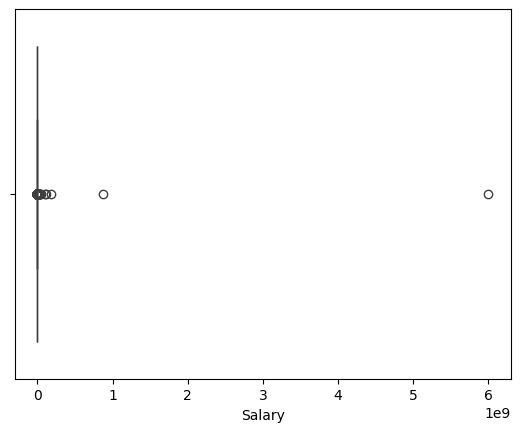

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'Salary' is the column you want to plot
sns.boxplot(x=df['Salary'])
plt.show()

In [ ]:
#What is the size of the dataset?
len(df)

28091

In [ ]:
df.isna().sum()# This shows you the total number of missing values per column

,0
Timestamp,0
Age,0
Industry,74
Job title,1
Context,20824
Salary,0
Compensation,7308
Currency,0
Other currency,27884
Salary context,25047


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28091 entries, 0 to 28090
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           28091 non-null  object 
 1   Age                                 28091 non-null  object 
 2   Industry                            28017 non-null  object 
 3   Job title                           28090 non-null  object 
 4   Context                             7267 non-null   object 
 5   Salary                              28091 non-null  int64  
 6   Compensation                        20783 non-null  float64
 7   Currency                            28091 non-null  object 
 8   Other currency                      207 non-null    object 
 9   Salary context                      3044 non-null   object 
 10  Country                             28091 non-null  object 
 11  State                               23062

In [ ]:
#Write a code to return the number of rows with missing values under the column 'Compensation'?
# Hint: use isna().sum()
df.isna().sum() #this computes the missing values for all columns
df['Compensation'].isna().sum() #this computes for 'Compensation' only

7308

In [ ]:
#Write a code that returns the each column name with the number of missing values. This will come in handy later
#Output example as below
df.isna().sum()

,0
Timestamp,0
Age,0
Industry,74
Job title,1
Context,20824
Salary,0
Compensation,7308
Currency,0
Other currency,27884
Salary context,25047


In [ ]:
print(df.columns)

Index(['Timestamp', 'Age', 'Industry', 'Job title', 'Context', 'Salary',
       'Compensation', 'Currency', 'Other currency', 'Salary context',
       'Country', 'State', 'City', 'Overall years of experience',
       'Years of experience in current job', 'Education level', 'Gender',
       'Race'],
      dtype='object')


### **1.1 Dropping columns with too many missing values**

In [ ]:
#Drop columns 'context', 'Other currency', 'Salary context'
df = df.drop(columns=['Context','Other currency', 'Salary context'])

In [ ]:
df.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28091 entries, 0 to 28090
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           28091 non-null  object 
 1   Age                                 28091 non-null  object 
 2   Industry                            28017 non-null  object 
 3   Job title                           28090 non-null  object 
 4   Salary                              28091 non-null  int64  
 5   Compensation                        20783 non-null  float64
 6   Currency                            28091 non-null  object 
 7   Country                             28091 non-null  object 
 8   State                               23062 non-null  object 
 9   City                                28009 non-null  object 
 10  Overall years of experience         28091 non-null  object 
 11  Years of experience in current job  28091

### **1.2 Quick analysis of missing values- Compensation**

In [ ]:
x = df[df['Compensation'].isna()]
x.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
5,4/27/2021 11:02:46,25-34,Education (Higher Education),Scholarly Publishing Librarian,62000,NaN,USD,USA,New Hampshire,Hanover,8 - 10 years,2 - 4 years,Master's degree,Man,White
7,4/27/2021 11:03:00,25-34,Education (Primary/Secondary),Librarian,50000,NaN,USD,United States,Arizona,Yuma,5-7 years,5-7 years,Master's degree,Man,White
14,4/27/2021 11:03:11,18-24,Health care,Patient care coordinator,32000,NaN,CAD,Canada,NaN,Remote,1 year or less,1 year or less,College degree,Woman,White
17,4/27/2021 11:03:19,45-54,Art & Design,graphic designer,59000,NaN,USD,usa,California,Pomona,21 - 30 years,21 - 30 years,College degree,Woman,White


In [ ]:
#Let's take a look at compensation for librarian from the original dataframe
df[df['Industry']=='Librarian']

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
2450,4/27/2021 11:44:24,35-44,Librarian,"Digital Initiatives Archivist, Senior",66703,0.0,USD,United States,Florida,Ft. Lauderdale,11 - 20 years,11 - 20 years,Master's degree,Woman,White
13187,4/28/2021 12:11:05,35-44,Librarian,Adult Services Librarian,45700,NaN,USD,USA,New York,Johnson City,8 - 10 years,5-7 years,Master's degree,Non-binary,White
21760,4/30/2021 16:24:12,25-34,Librarian,teen librarian,40700,0.0,USD,USA,Ohio,Marion,8 - 10 years,11 - 20 years,Master's degree,Woman,White


### **1.3 Dropping missing values**

In [ ]:
# Notes
# We can drop missing values here using dropna() function.
# If we do dropna() without specifying any parameter, it will drop rows that has even 1 missing values
# If we do dropna(thresh=2) it will drop rows that has more than 2 missing values
# If we do dropna(how=all) it will drop only rows where all values are missing

In [ ]:
df_dropna = df.dropna()
df_dropna.info()
#Compare the number of rows with the original dataset
#16974 rows vs originally 27989 rows

<class 'pandas.core.frame.DataFrame'>
Index: 17016 entries, 0 to 28090
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           17016 non-null  object 
 1   Age                                 17016 non-null  object 
 2   Industry                            17016 non-null  object 
 3   Job title                           17016 non-null  object 
 4   Salary                              17016 non-null  int64  
 5   Compensation                        17016 non-null  float64
 6   Currency                            17016 non-null  object 
 7   Country                             17016 non-null  object 
 8   State                               17016 non-null  object 
 9   City                                17016 non-null  object 
 10  Overall years of experience         17016 non-null  object 
 11  Years of experience in current job  17016 non-

### **1.4 Impute missing values with most frequent**

In [ ]:
# Notes
# A simple method where we don't analyse per column.
# We can impute missing values for all related columns using most frequent.
# Imputed values can be the mean, median. This is changed in the 'strategy' parameter.
# There are other simple methods for imputing missing values. Eg fill.na()

In [ ]:
from sklearn.impute import SimpleImputer
#Here we using sklearn.impute.SimpleImputer
#Function is to replace missing values using a descriptive statistic(e.g. mean, median or most frequent)along each column or using a constant value
#df2 = df.copy() #so that you are not overwriting the original dataframe, #overiding
#df_impute = df.copy() #many times it is wise to copy the dataframe rather than reassign it
most_frequent_imputer = SimpleImputer(strategy='most_frequent') #change strategy here if want to use median etc.
df.iloc[:,:] = most_frequent_imputer.fit_transform(df)
df.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000.0,GBP,United Kingdom,California,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,0.0,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [ ]:
df.isna().sum() #There is no missing values/NaN anymore. So can consider as a cleaned datasets

,0
Timestamp,0
Age,0
Industry,0
Job title,0
Salary,0
Compensation,0
Currency,0
Country,0
State,0
City,0


# **2. Noisy data**


In [ ]:
# Noise can be random errors and/or outliers.
# It can also be non-sensible data

### **2.1 Remove outliers**


In [ ]:
# Use boxplot or histograms to find outliers (df.boxplot() or df.hist())
# Outliers are values that are waaay higher or lower than most of the data. Usually there are not many data points like this. So we can consider this as noise
# It seems salary and compensation has many outliers. Let's remove them

<Axes: >

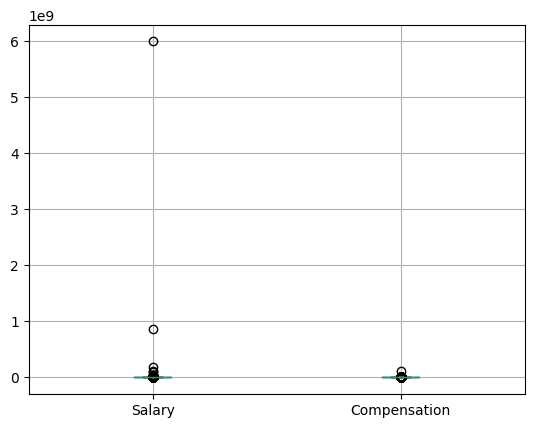

In [ ]:
df.boxplot() # There are

<Axes: >

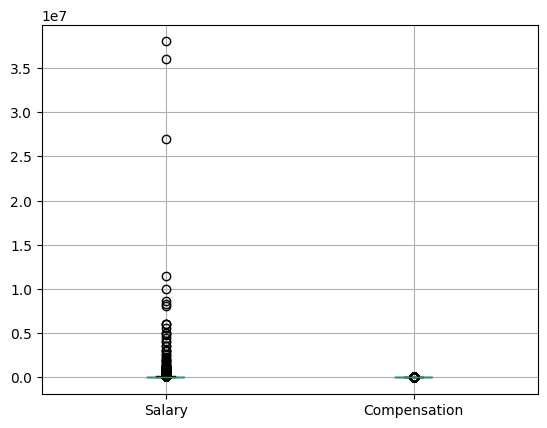

In [ ]:
from scipy import stats
df=df[(np.abs(stats.zscore(df['Salary'])) < 1.5)] #replace 1.5 with your own threshold
df=df[(np.abs(stats.zscore(df['Compensation'])) < 0.75)]
df.boxplot()

### **2.2 Remove non sensible values**

In [ ]:
df['Salary'].min() # why minimum is zero? minimum from Dr is 17000. I think the datasets add many new responses and some salary amount very outrageous

0

In [ ]:
print(df['Salary'].describe())
print('is it really true that the min salary is zero?::',df['Salary'].min())
'''
salary_zero = df[df['Salary']==0]
print(len(salary_zero))
df[df['Salary']==0].count()
df[df['Salary']==0]['Salary'].count()
df[df['Salary']==0]
'''

count    2.686800e+04
mean     9.433894e+04
std      4.017279e+05
min      0.000000e+00
25%      5.300000e+04
50%      7.450000e+04
75%      1.040000e+05
max      3.800000e+07
Name: Salary, dtype: float64
is it really true that the min salary is zero?:: 0


"\nsalary_zero = df[df['Salary']==0]\nprint(len(salary_zero))\ndf[df['Salary']==0].count()\ndf[df['Salary']==0]['Salary'].count()\ndf[df['Salary']==0]\n"

### **How to subset**

<Axes: >

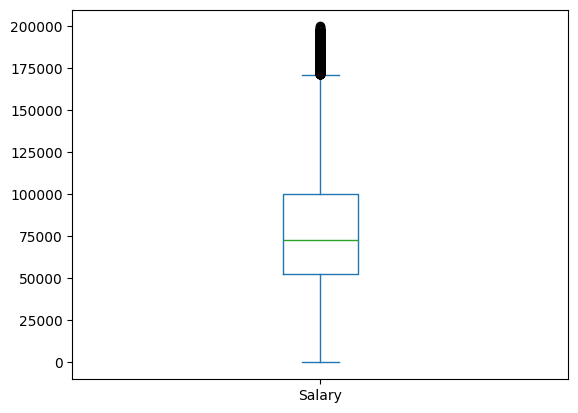

In [ ]:
#Subsetting/Slicing : is taking a subset of the dataset
df2 = df.copy()
a = df2[df2['Salary']<200000]
a['Salary'].plot(kind='box')

In [ ]:
df[df['Salary']<500]
df = df[df['Salary']>=17000] #any data that has annual salary of less than 17k is non sensible. so we 'drop' it by subset

# **3. Inconsistent data**

In [ ]:
# Find 'duplicated' rows. For example 'University Malaya' , 'UM', 'Universiti Malaya' should be the same. One way is to use fuzzy matching
# (fuzzywuzzy package)
# Find typos
# Warning , this is very tedious

### **3.1 Check for each columns. Example is 'Gender'**

In [ ]:
# Print out the unique items for each columns using df['column].unique()
# You'll see some are not that unique. Using the 'Gender' column, I found that there is 'Other or prefer not to answer' and 'Prefer not to
# answer'. Let's just group them into 'Other'
# Try checking columns with the lowest number of unique itmes first

In [ ]:
df['Gender'].unique()

array(['Woman', 'Non-binary', 'Man', 'Other or prefer not to answer',
       'Prefer not to answer'], dtype=object)

In [ ]:
print('--Columns and their number of unique items--')
df.nunique()

--Columns and their number of unique items--


,0
Timestamp,23321
Age,7
Industry,1177
Job title,13794
Salary,3443
Compensation,622
Currency,11
Country,347
State,127
City,4680


In [ ]:
#Forcing colab to print out all in the y (stored as ndarray)
#Check the unique items for Gender
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
#y = df['Industry'].unique()
y = df['Gender'].unique()
print(f'There are {len(y)} unique items ')
print(y)

There are 5 unique items 
['Woman' 'Non-binary' 'Man' 'Other or prefer not to answer'
 'Prefer not to answer']


In [ ]:
# Remove redundancy by using df.replace()
df = df.replace('Other or prefer not to answer','Prefer Not Answer')
#df = df.replace('Prefer not to answer','Prefer Not to Answer')

In [ ]:
# Check whether the values have been replaced or not
y = df['Gender'].unique()
print(f'There are {len(y)} unique items ')
print(y)

There are 5 unique items 
['Woman' 'Non-binary' 'Man' 'Prefer Not Answer' 'Prefer not to answer']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26619 entries, 0 to 28090
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           26619 non-null  object 
 1   Age                                 26619 non-null  object 
 2   Industry                            26619 non-null  object 
 3   Job title                           26619 non-null  object 
 4   Salary                              26619 non-null  int64  
 5   Compensation                        26619 non-null  float64
 6   Currency                            26619 non-null  object 
 7   Country                             26619 non-null  object 
 8   State                               26619 non-null  object 
 9   City                                26619 non-null  object 
 10  Overall years of experience         26619 non-null  object 
 11  Years of experience in current job  26619 non-

**Since all features/columns are now in non-null condition. Thus, this datasets is very very cleaned, which is known as cleaned datasets**